# Sprint 1 — Model Benchmarking (Şampiyon Model Seçimi)

4 farklı embedding modeli aynı 50 görseller üzerinde kıyaslanır:
- **ResNet50**, **EfficientNet-B0**, **EfficientNet-B4**, **CLIP**

Her model ayrı ChromaDB koleksiyonuna kaydedilir; sonuçlar matplotlib ile görselleştirilir.

## Hücre 1 — Ortam ve Importlar

In [1]:
import importlib
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

%load_ext autoreload
%autoreload 2

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Önbelleğe alınmış eski modülleri temizle (src/ değişikliklerinden sonra)
for mod_name in list(sys.modules):
    if mod_name.startswith("src."):
        del sys.modules[mod_name]

from src.config import (
    BATCH_SIZE,
    BENCHMARK_MODELS,
    CHROMA_PERSIST_DIR,
    DEFAULT_COMPANY_ID,
    TEST_SUBSET_DIR,
)
from src.models import FeatureExtractorFactory, get_extractor
from src.vector_store import ChromaVectorStore

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
logger = logging.getLogger("benchmark")

COMPANY_ID = DEFAULT_COMPANY_ID
TOP_K = 3
MODEL_NAMES = list(BENCHMARK_MODELS.keys())

import src.models.feature_extractor as _fe

print(f"Proje: {PROJECT_ROOT}")
print(f"Modeller: {MODEL_NAMES}")
print(f"CLIP fix yüklü: {hasattr(_fe.CLIPExtractor, '_to_feature_tensor')}")

Proje: /Users/mac/Desktop/Wp_Bot
Modeller: ['resnet50', 'efficientnet_b0', 'efficientnet_b4', 'clip']
CLIP fix yüklü: True


## Hücre 2 — Test Alt Kümesini Yükle (50 Görsel)

In [2]:
image_paths = sorted(
    p for p in TEST_SUBSET_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
)

if len(image_paths) < 2:
    raise FileNotFoundError(
        f"{TEST_SUBSET_DIR} boş veya yetersiz. "
        "Önce sprint1_embedding_pipeline.ipynb ile 50 görsel oluşturun."
    )

# Benchmark sorgu görseli (ilk dosya; istenirse değiştirilebilir)
QUERY_PATH = image_paths[0]

print(f"Görsel sayısı: {len(image_paths)}")
print(f"Sorgu görseli: {QUERY_PATH.name}")

Görsel sayısı: 3121
Sorgu görseli: 0006.01.019.00211_0166_1.jpg


## Hücre 3 — Modelleri Sırayla Yükle, Vektörle ve ChromaDB'ye Kaydet

Her model farklı koleksiyona yazılır; tüm kayıtlarda `company_id="test_firmasi_1"`.

In [3]:
benchmark_results: dict = {}

for model_name in tqdm(MODEL_NAMES, desc="Modeller"):
    collection_name = BENCHMARK_MODELS[model_name]
    logger.info("=== %s → %s ===", model_name, collection_name)

    try:
        extractor = get_extractor(model_name)
        store = ChromaVectorStore(
            persist_directory=CHROMA_PERSIST_DIR,
            collection_name=collection_name,
            company_id=COMPANY_ID,
        )

        embeddings, ids = extractor.extract_from_paths(
            image_paths, batch_size=BATCH_SIZE
        )

        extra_meta = [{"model": model_name}] * len(ids)
        saved = store.add_embeddings(ids, embeddings, extra_metadata=extra_meta)

        benchmark_results[model_name] = {
            "saved": saved,
            "embedding_dim": extractor.embedding_dim,
        }
        print(
            f"✓ {model_name}: {saved} vektör | dim={extractor.embedding_dim} | "
            f"koleksiyon={collection_name}"
        )

        # RAM temizliği — sonraki model için
        del extractor
        import gc
        import torch
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as exc:
        logger.exception("%s başarısız: %s", model_name, exc)
        raise

print("\nTüm modeller indekslendi.")

Modeller:   0%|          | 0/4 [00:00<?, ?it/s]

2026-08-10 17:32:58,718 | INFO | benchmark | === resnet50 → collection_resnet ===
2026-08-10 17:32:59,162 | INFO | src.models.feature_extractor | resnet50 hazır | boyut=2048 | cihaz=cpu
2026-08-10 17:32:59,229 | INFO | src.vector_store.chroma_store | ChromaDB koleksiyonu hazır | firma: test_firmasi_1 | kayıt: 3121


KeyboardInterrupt: 

## Hücre 4 — Top-3 Benzerlik Sorgusu (Tüm Modeller)

In [21]:
import torch
import random

QUERY_PATH = random.choice(image_paths)
TOP_K = 5

query_results: dict = {}

for model_name in MODEL_NAMES:
    extractor = get_extractor(model_name)
    store = ChromaVectorStore(
        CHROMA_PERSIST_DIR,
        BENCHMARK_MODELS[model_name],
        COMPANY_ID,
    )

    batch, _ = extractor.preprocess_paths([QUERY_PATH])
    if batch.numel() == 0:
        raise RuntimeError(f"Sorgu görseli işlenemedi: {QUERY_PATH}")

    query_vec = extractor.extract(batch)[0].tolist()
    hits = store.query_similar(query_vec, n_results=TOP_K + 1)

    # Sorgunun kendisi çıkarsa atla, top-3 benzersiz sonuç al
    ranked_ids = []
    ranked_dists = []
    for doc_id, dist in zip(hits["ids"][0], hits["distances"][0]):
        if doc_id == QUERY_PATH.name:
            continue
        ranked_ids.append(doc_id)
        ranked_dists.append(dist)
        if len(ranked_ids) >= TOP_K:
            break

    query_results[model_name] = {
        "ids": ranked_ids,
        "distances": ranked_dists,
    }
    print(f"{model_name}: {ranked_ids}")

    del extractor
    import gc
    gc.collect()

2026-08-10 15:57:47,896 | INFO | src.models.feature_extractor | resnet50 hazır | boyut=2048 | cihaz=cpu
2026-08-10 15:57:47,902 | INFO | src.vector_store.chroma_store | ChromaDB koleksiyonu hazır | firma: test_firmasi_1 | kayıt: 3121


resnet50: ['0949.00.015.00098_0032_1.jpg', '0076.00.014.01094_0024_1.jpg', '0308.00.008.00174_0001_1.jpg', '0614.00.014.00599_0039_1.jpg', '0255.01.008.00191_0024_1.jpg']


2026-08-10 15:57:48,218 | INFO | src.models.feature_extractor | efficientnet_b0 hazır | boyut=1280 | cihaz=cpu
2026-08-10 15:57:48,224 | INFO | src.vector_store.chroma_store | ChromaDB koleksiyonu hazır | firma: test_firmasi_1 | kayıt: 3121


efficientnet_b0: ['0949.00.014.00040_0001_1.jpg', '0098.00.014.01122_0001_1.jpg', '0255.01.008.00287_0020_1.jpg', '0949.00.008.00202_0001_1.jpg', '0076.00.008.00519_0001_1.jpg']


2026-08-10 15:57:48,831 | INFO | src.models.feature_extractor | efficientnet_b4 hazır | boyut=1792 | cihaz=cpu
2026-08-10 15:57:48,836 | INFO | src.vector_store.chroma_store | ChromaDB koleksiyonu hazır | firma: test_firmasi_1 | kayıt: 3121


...

2026-08-10 15:57:49,811 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-08-10 15:57:49,973 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-08-10 15:57:50,134 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
2026-08-10 15:57:50,299 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-08-10 15:57:50,466 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-08-10 15:57:50,626 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-08-10 15:57:52,973 | INFO | src.models.feature_extractor | clip hazır | model=openai/clip-vit-base-patch32 | boyut=512 | pad=True | cihaz=cpu
2026-08-10 15:57:52,976 | INFO | src.vector_store.chroma_store | ChromaDB koleksiyonu hazır | firma: test_firmasi_1 | kayıt: 3121
2026-08-10 15:57:53,005 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32 "HTTP/1.1 200 OK"
2026-08-10 15:57:53,178 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/main "HTTP/1.1 200 OK"
2026-08-10 15:57:53,362 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/discussions?p=0 "HTTP/1.1 200 OK"
2026-08-10 15:57:53,533 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
2026-08-10 15:57:53,694 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32

clip: ['0949.00.015.00099_0011_1.jpg', '0949.00.015.00098_0032_1.jpg', '0949.00.012.00045_0001_1.jpg', '0949.00.012.00077_0001_1.jpg', '0949.00.012.00047_0001_1.jpg']


2026-08-10 15:57:53,936 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors "HTTP/1.1 302 Found"


## Hücre 5 — A/B Görselleştirme (Matplotlib)

Her satır bir model: **[Sorgu] | Top-1 | Top-2 | Top-3**

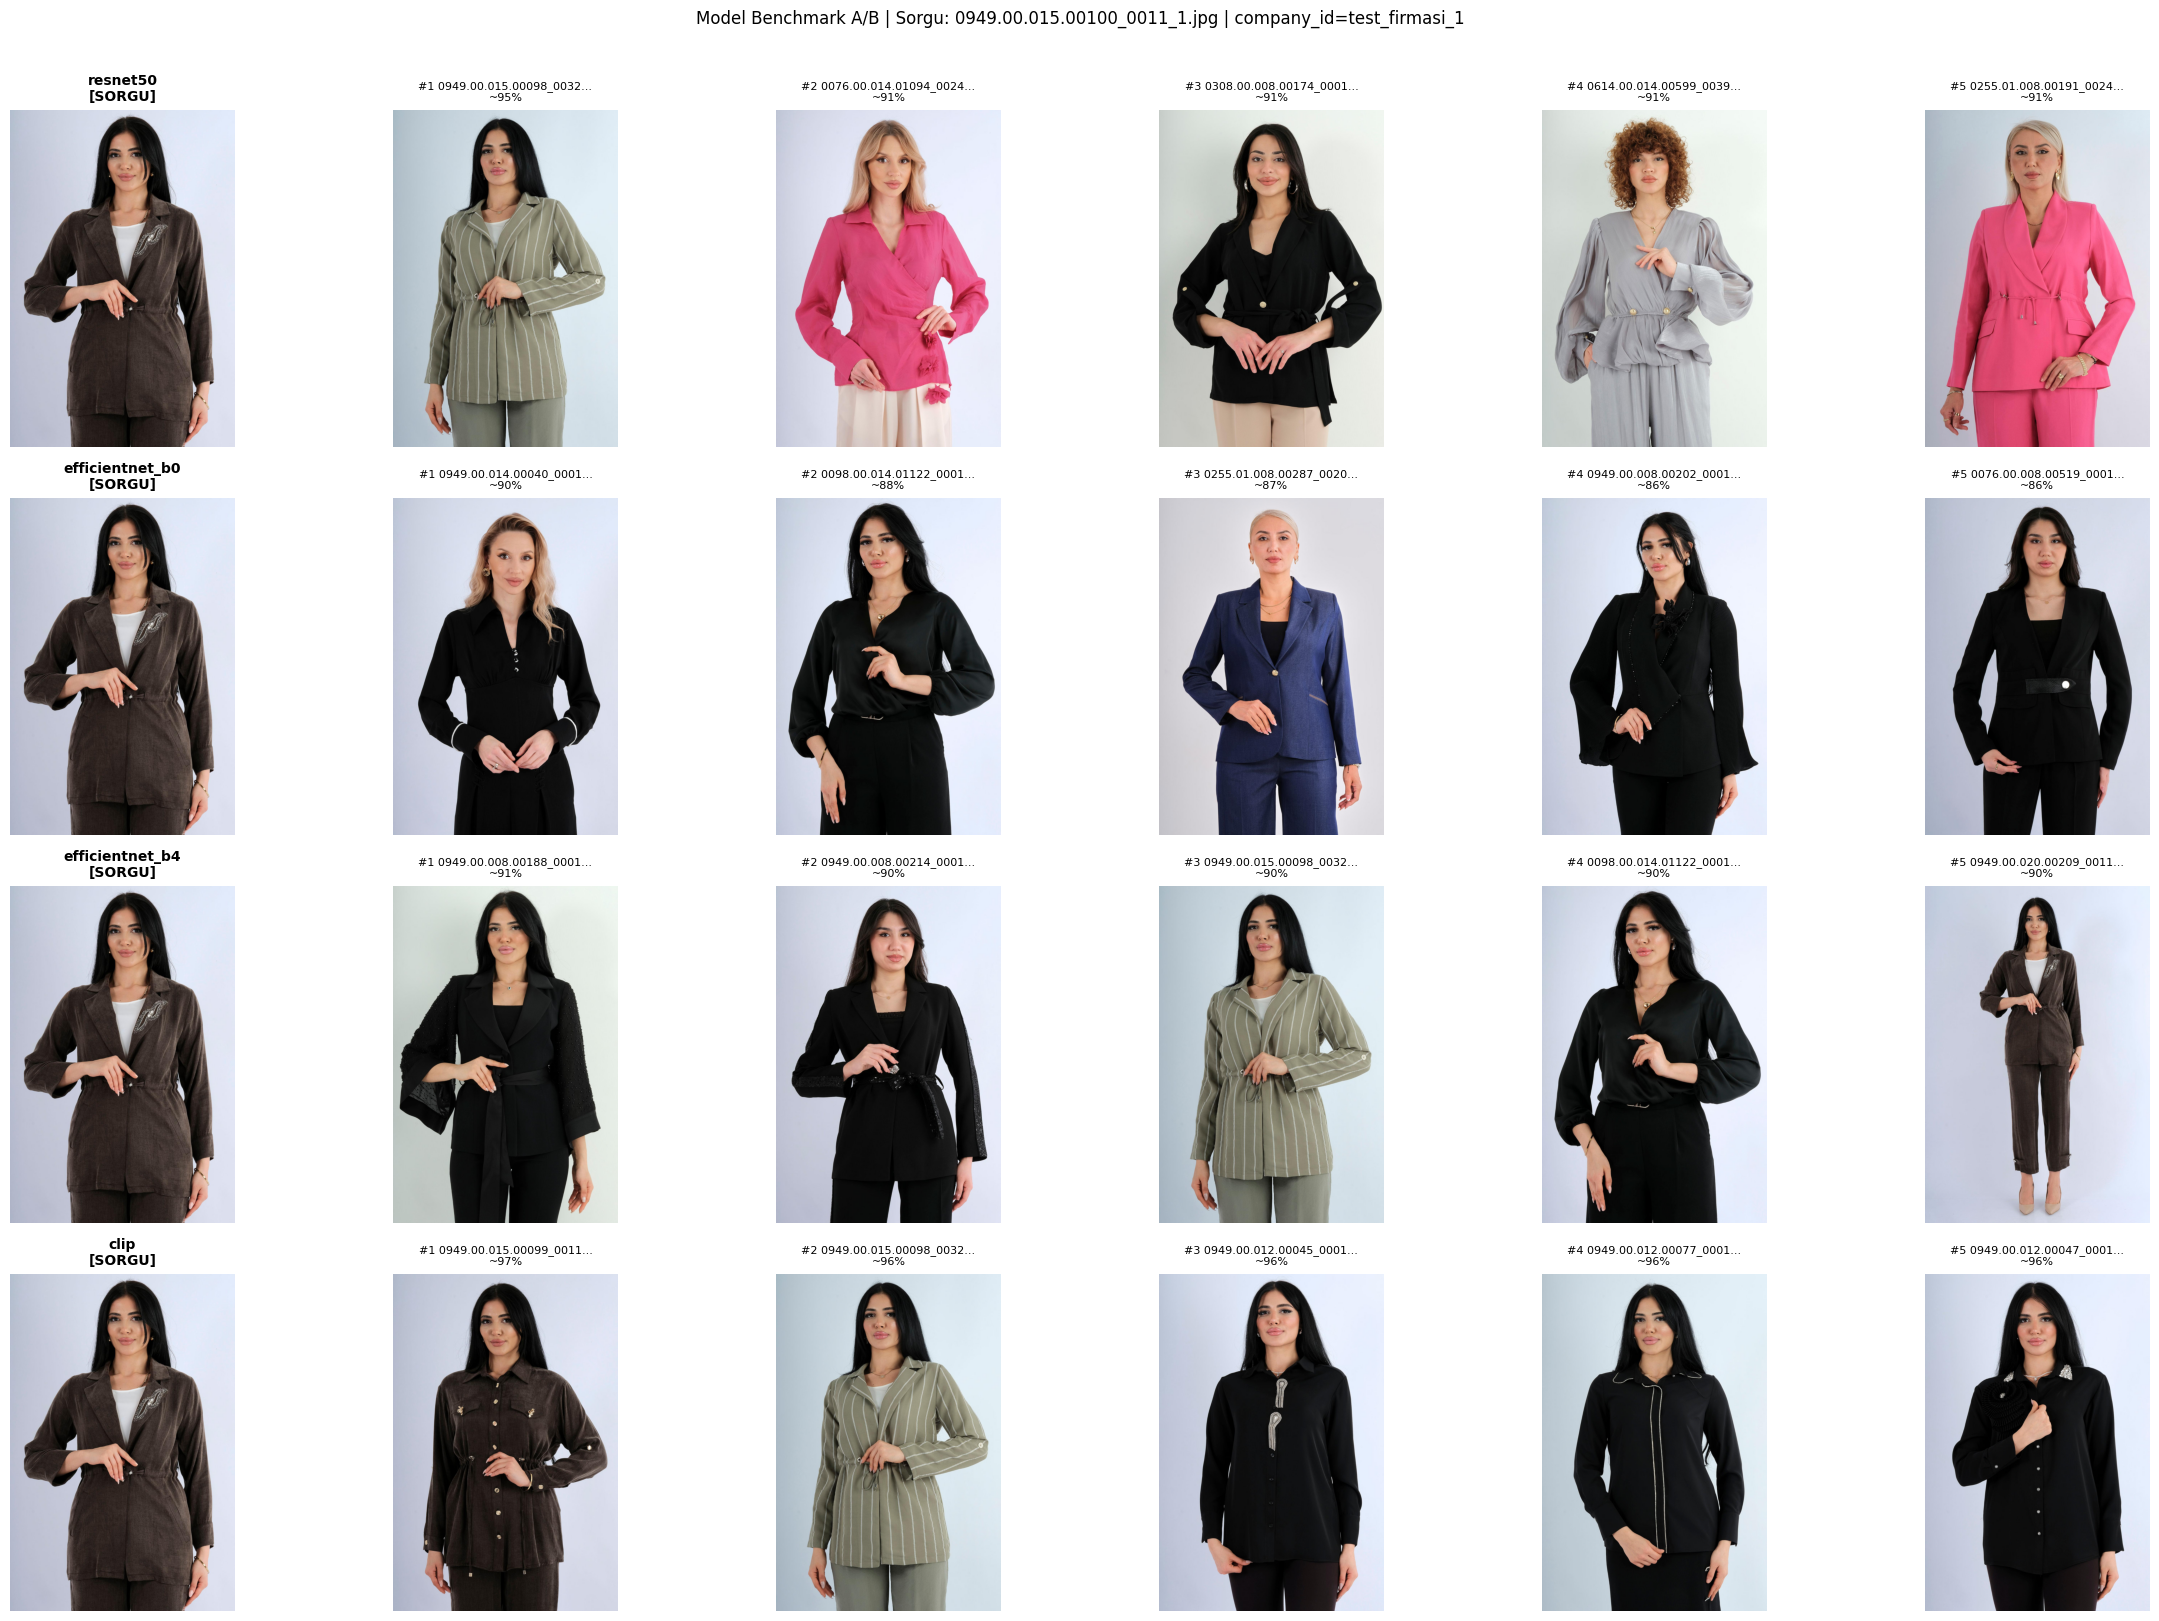

In [22]:
def load_display_image(filename: str) -> Image.Image:
    path = TEST_SUBSET_DIR / filename
    return Image.open(path).convert("RGB")


n_models = len(MODEL_NAMES)
n_cols = 1 + TOP_K  # sorgu + top-3

fig, axes = plt.subplots(n_models, n_cols, figsize=(4 * n_cols, 4 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)

for row, model_name in enumerate(MODEL_NAMES):
    # Sorgu görseli
    axes[row, 0].imshow(load_display_image(QUERY_PATH.name))
    axes[row, 0].set_title(f"{model_name}\n[SORGU]", fontsize=10, fontweight="bold")
    axes[row, 0].axis("off")

    hits = query_results[model_name]
    for col in range(TOP_K):
        ax = axes[row, col + 1]
        if col < len(hits["ids"]):
            doc_id = hits["ids"][col]
            dist = hits["distances"][col]
            ax.imshow(load_display_image(doc_id))
            sim_pct = max(0, (1 - dist / 2)) * 100
            ax.set_title(f"#{col+1} {doc_id[:22]}...\n~{sim_pct:.0f}%", fontsize=8)
        ax.axis("off")

plt.suptitle(
    f"Model Benchmark A/B | Sorgu: {QUERY_PATH.name} | company_id={COMPANY_ID}",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()

## Hücre 6 — Özet Tablo

In [23]:
print(f"{'Model':<20} {'Koleksiyon':<30} {'Boyut':<8} {'Kayıt'}")
print("-" * 70)
for model_name in MODEL_NAMES:
    info = benchmark_results[model_name]
    print(
        f"{model_name:<20} "
        f"{BENCHMARK_MODELS[model_name]:<30} "
        f"{info['embedding_dim']:<8} "
        f"{info['saved']}"
    )

print("\nŞampiyon modeli seçmek için yukarıdaki A/B görselini inceleyin.")

Model                Koleksiyon                     Boyut    Kayıt
----------------------------------------------------------------------
resnet50             collection_resnet              2048     3121
efficientnet_b0      collection_efficientnet_b0     1280     3121
efficientnet_b4      collection_efficientnet_b4     1792     3121
clip                 collection_clip                512      3121

Şampiyon modeli seçmek için yukarıdaki A/B görselini inceleyin.
